In [1]:
import pandas as pd
from astropy import units as u
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# CHIME package import
from chime import calibration 
from chime import util 

# Manual reduction to csv

In [2]:
def update_log_entry(logfile_path, date, target_freq, target_flux, coeff, sun_projection_on_chime):
    height, center, width, baseline = coeff
    df = pd.read_csv(logfile_path)
    update_mask = np.where((df["date"] == date) & (df["target_freq"] == target_freq))
    for index in update_mask[0]:
        df.loc[index, "fit_success"] = False

    new_row_data = [date,target_freq,target_flux,height,center,width,baseline,sun_projection_on_chime,True]
    df.loc[len(df)] = new_row_data
    df.to_csv(logfile_path, index=False)    

In [3]:
date = "2026_096"
data_dir = f"/users/dbautist/CHIME_landing_directory/{date}/"
fit_frequency = 410
outdir = f"/home/scratch/dbautist/TEST/{fit_frequency}/"


# fit_frequency = 610
data_grid, frequency, timestamps = calibration.load_CHIME_data(data_dir)
start_time = timestamps[0]

if fit_frequency == 610:
    index = np.argmin(np.abs(frequency - 610))
    flux = calibration.median_610
elif fit_frequency == 410:
    index = np.argmin(np.abs(frequency - 410))
    flux = calibration.median_410
else:
    print("please set fit_frequency to either 610 or 410 MHz")


In [4]:
timestamps[0].strftime("%Y-%m-%dT%H:%M:%S%:z")

'2026-04-06T04:00:05+00:00'

In [5]:
timestamps[0].strftime("%Y-%m-%d")

'2026-04-06'

(0.0, 100000000.0)

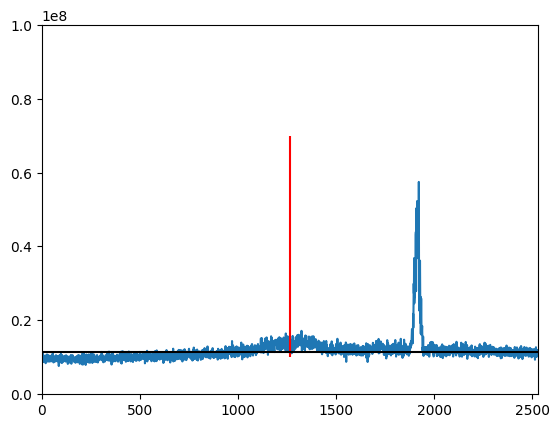

In [6]:
lower = 0
upper = len(data_grid)

closest_approach_index = upper // 2

full_median = np.median(data_grid[lower:upper, index])

plt.figure()
xx = np.arange(lower, upper)
plt.plot(xx, data_grid[lower:upper, index])
plt.vlines(closest_approach_index, 1e7, 7e7, color="red")
plt.hlines(full_median, xx.min(), xx.max(), color="black")
plt.xlim(lower, upper)
plt.ylim(0, 1e8)

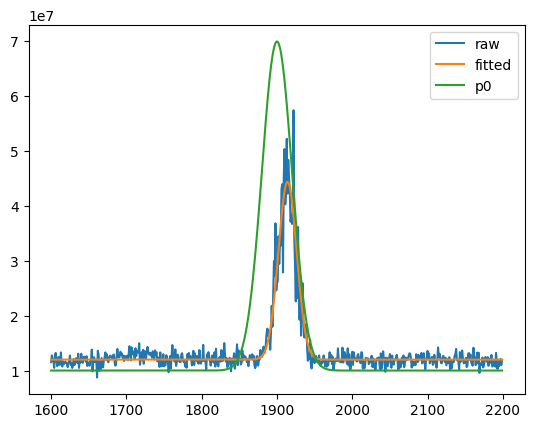

In [7]:
center_guess = 1900
lower = max((0, center_guess - 300))
upper = min((center_guess + 300, len(data_grid)-1))


ydata = data_grid[lower:upper, index].copy()
xdata = np.arange(lower, upper)

# mask = np.where(ydata > 3e7)#np.where(ydata > 1e9)
# ydata[mask] = np.median(ydata)
xx = np.linspace(lower, upper, num=len(ydata))#np.arange(lower, upper) # may need to be linspace

# define guessing parameters
bounds = ((0,np.min(xx),3,0), (1e9, np.max(xx), 100, np.inf))
p0 = (6e7, center_guess, 20, 1e7)
    
# fit gaussian and calibrate based on fit values
coeff, cov = curve_fit(calibration.gaussian, xx, ydata, p0=p0, bounds=bounds)
# coeff[3] = full_median
plt.figure()
plt.plot(xdata, ydata, label="raw")
plt.plot(xdata, calibration.gaussian(xdata, *coeff), label='fitted')
plt.plot(xdata, calibration.gaussian(xdata, *p0), label='p0')
# plt.xlim(1810, 1950)
# plt.ylim(0, 5e8)
plt.legend()
# plt.ylim(0, 2e8)

In [8]:
height, center, width, baseline = coeff
sun_df = pd.read_csv(f"/users/dbautist/CHIME_landing_directory/sunPosition/{date}_CHIME.csv")

closest_approach_index = calibration.get_closest_position(sun_df, timestamps)

sun_alt, sun_az = calibration.solar_position(timestamps[closest_approach_index], lat=calibration.CHIME_latitude, lon=calibration.CHIME_longitude, unit=u.deg)
sun_vector =      calibration.normal_vector(sun_az, sun_alt, degrees=True)
chime_vector =    calibration.normal_vector(calibration.CHIME_azimuth, calibration.CHIME_altitude, degrees=True)

sun_projection_on_chime = np.dot(sun_vector, chime_vector)
projected_flux = flux * sun_projection_on_chime

counts_to_flux = projected_flux / height
calibrated_grid = data_grid * counts_to_flux
labels = ['height', 'center', 'width', 'baseline']
for i in range(len(coeff)):
    print(f"{labels[i]}: {coeff[i]}")
print(f"counts to flux: {counts_to_flux}")

height: 32426607.404011656
center: 1914.0467721893046
width: 12.183608181045358
baseline: 11995570.614491489
counts to flux: 0.011014935083467316


In [9]:
print(f"sun projection: {sun_projection_on_chime}")
print(f"closest approach: {timestamps[closest_approach_index]} UTC")

sun projection: 0.7289326031270796
closest approach: 2026-04-06 20:01:26.069210+00:00 UTC


In [ ]:
logfile_path = "/users/dbautist/CHIME_landing_directory/calibration_log.csv"

obs_time = start_time.strftime("%Y-%m-%dT%H:%M:%S%:z")
mean_spectrum = np.nanmean(calibrated_grid, axis=0)
scan_name = start_time.strftime("%Y-%m-%d")

data_dict = {"instrument":"chime_gbo",
                 "receiver":"chime",
                 "polarization":"I",
                 "intensity_unit":"Jy",
                 "scan_name":scan_name,
                 "scan_datetime":obs_time, 
                 "frequency":frequency,
                 "intensity":mean_spectrum
                 }
df = pd.DataFrame(data_dict)

util.check_dir(f"{outdir}/{date}/")
df.to_csv(f"{outdir}/{date}/{date}.csv", index=False)
update_log_entry(logfile_path, date, fit_frequency, flux, coeff, sun_projection_on_chime)
print(f"written to {outdir}/{date}/{date}.csv")